# 05 · Islands of popularity

**The question:** are hit songs scattered randomly through the space of possible sounds, or do **popular songs cluster into 'islands'** — regions of acoustic space where music tends to catch on? We work in the same 9-D feature space as notebook 01, colored now by `popularity` (0–100).

*Caveat:* Spotify `popularity` is a recent-ish snapshot, so it tilts toward contemporary sounds. We read 'islands' as *acoustic* regions that are popular, not a claim about all time.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'analysis'))
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
from common import load_genre, load_timeline, AUDIO, zscore
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
RNG = 42
a = load_genre()
# one row per track, keeping its highest observed popularity
uniq = a.sort_values('popularity').drop_duplicates('track_id', keep='last').reset_index(drop=True)
Xs = zscore(uniq)
pop = uniq['popularity'].to_numpy()
print(f'{len(uniq):,} unique tracks · mean popularity {pop.mean():.1f}')

176,773 unique tracks · mean popularity 36.5


## Step 1 — Hits are rare
Most songs score low; only a sliver are very popular. So 'islands' means: do those rare hits sit together?

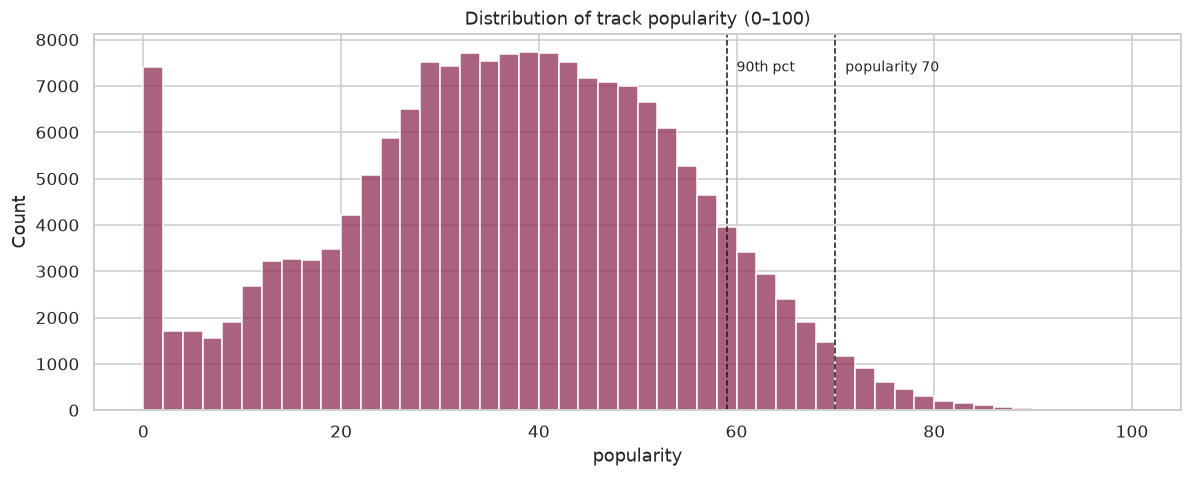

In [2]:
plt.figure(figsize=(11, 4.5))
sns.histplot(pop, bins=50, color='#8f2d56')
for p, lbl in [(np.percentile(pop,90),'90th pct'), (70,'popularity 70')]:
    plt.axvline(p, color='k', ls='--', lw=1); plt.text(p+1, plt.ylim()[1]*.9, lbl, fontsize=9)
plt.title('Distribution of track popularity (0–100)'); plt.xlabel('popularity')
plt.tight_layout(); plt.show()

## Step 2 — A popularity map of the sound-space
Project to 2-D (PCA) and hex-bin it, coloring each cell by the **mean popularity** of the songs in it. Bright cells are acoustic neighborhoods where music tends to be popular — the islands.

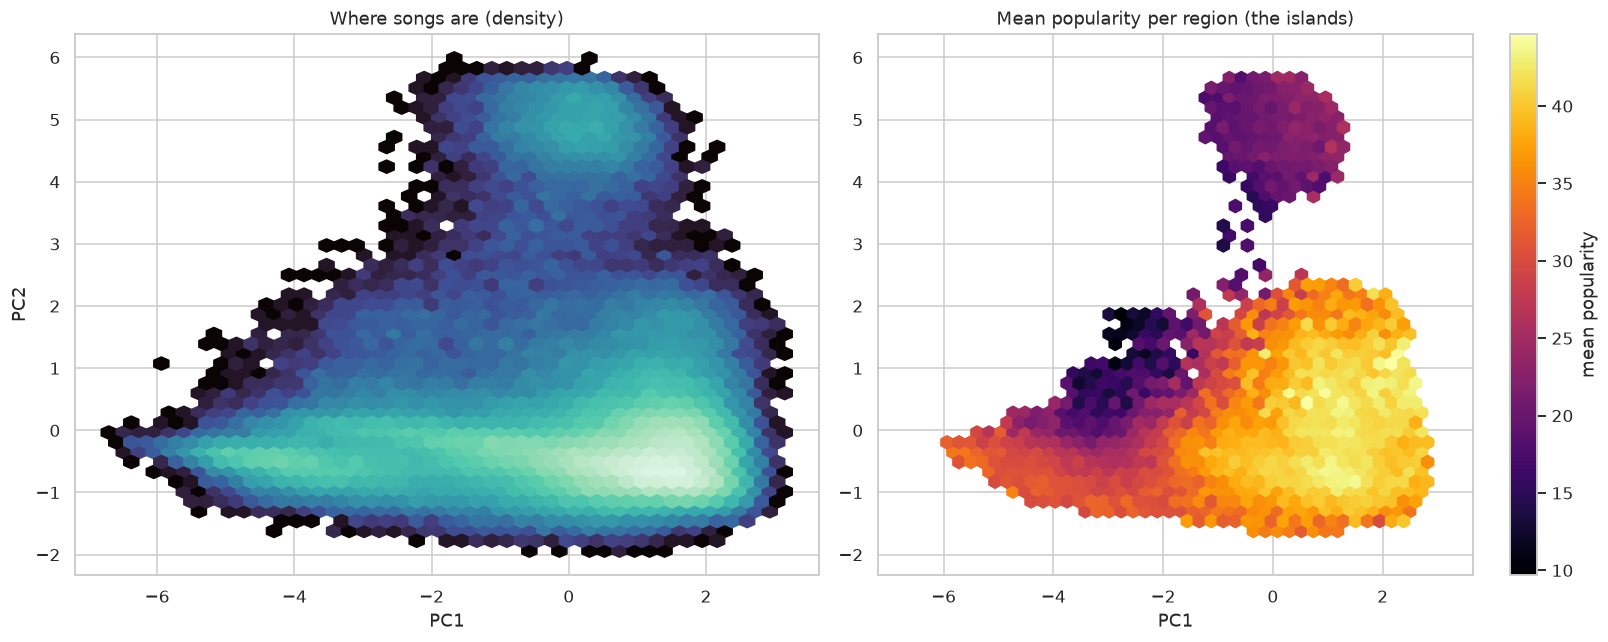

In [3]:
Z = PCA(n_components=2, random_state=RNG).fit_transform(Xs)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ax[0].hexbin(Z[:,0], Z[:,1], gridsize=45, cmap='mako', bins='log')
ax[0].set_title('Where songs are (density)'); ax[0].set_xlabel('PC1'); ax[0].set_ylabel('PC2')
hb = ax[1].hexbin(Z[:,0], Z[:,1], C=pop, reduce_C_function=np.mean, gridsize=45,
                  cmap='inferno', mincnt=20)
ax[1].set_title('Mean popularity per region (the islands)'); ax[1].set_xlabel('PC1')
fig.colorbar(hb, ax=ax[1], label='mean popularity'); plt.tight_layout(); plt.show()

**Takeaway:** popularity is *not* uniform — some regions of sound-space glow far hotter than others. Hits concentrate.

## Step 3 — Do popular songs have popular neighbors?
If islands are real, a song's *acoustic* neighbors should be more popular than average when the song itself is popular. We compare each sampled song's popularity to the mean popularity of its 10 nearest neighbors.

corr(own popularity, neighbors' popularity) = 0.50
neighbors of a top-10%% song average 44.1 popularity vs 36.5 overall (lift 1.2x)


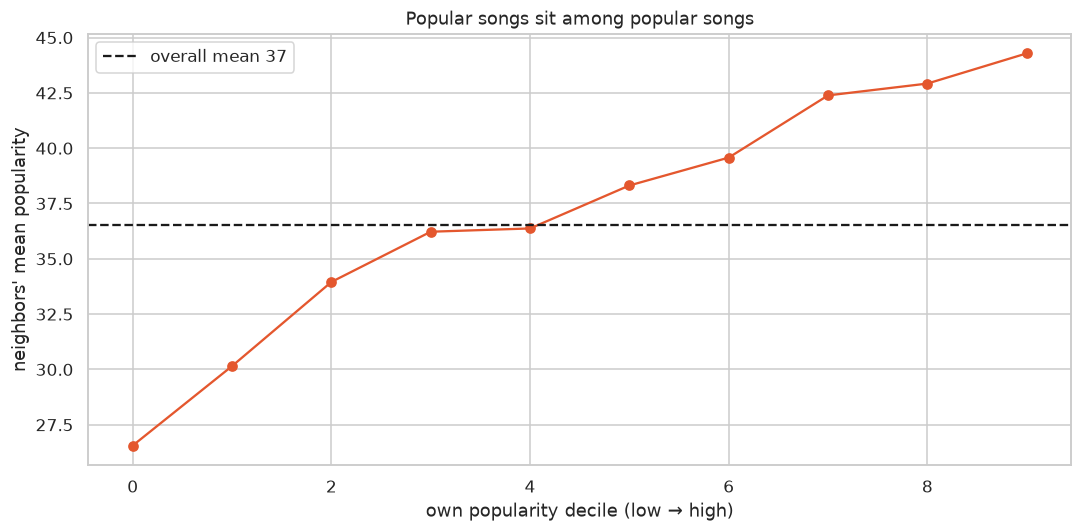

In [4]:
nn = NearestNeighbors(n_neighbors=11).fit(Xs)
rng = np.random.default_rng(RNG)
q = rng.choice(len(Xs), size=6000, replace=False)
_, idx = nn.kneighbors(Xs[q])
nbr_pop = pop[idx[:,1:]].mean(1)
r = np.corrcoef(pop[q], nbr_pop)[0,1]
# neighbor popularity lift for the top-decile-popular songs
hi = pop[q] >= np.percentile(pop, 90)
print(f'corr(own popularity, neighbors\' popularity) = {r:.2f}')
print(f'neighbors of a top-10%% song average {nbr_pop[hi].mean():.1f} popularity '
      f'vs {pop.mean():.1f} overall (lift {nbr_pop[hi].mean()/pop.mean():.1f}x)')
bins = pd.qcut(pop[q], 10, duplicates='drop')
grp = pd.DataFrame({'nbr': nbr_pop, 'bin': bins}).groupby('bin', observed=True)['nbr'].mean()
plt.figure(figsize=(10, 5))
plt.plot(range(len(grp)), grp.values, marker='o', color='#e4572e')
plt.axhline(pop.mean(), color='k', ls='--', label=f'overall mean {pop.mean():.0f}')
plt.xlabel('own popularity decile (low → high)'); plt.ylabel("neighbors' mean popularity")
plt.title('Popular songs sit among popular songs'); plt.legend(); plt.tight_layout(); plt.show()

**Takeaway:** a clear positive relationship — the more popular a song, the more popular its acoustic neighbors. Popularity is *spatially autocorrelated* in sound-space: islands, not noise.

## Step 4 — Naming the islands (k-means)
Cluster the sound-space and rank clusters by mean popularity. The hottest clusters are the 'hit islands'; we tag each with its dominant genre and a chart-topping example.

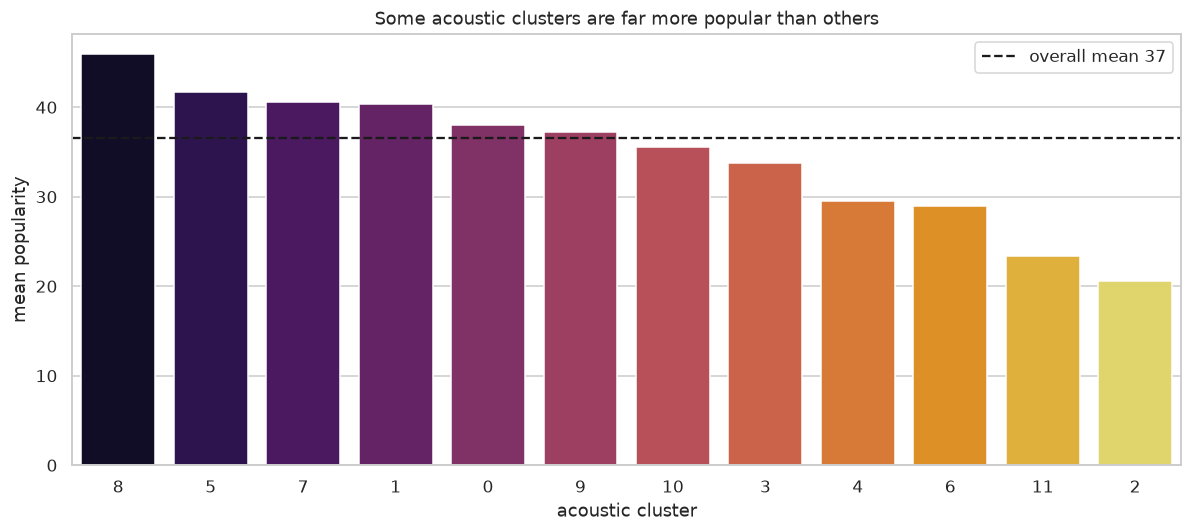

,mean_pop,n,top_genre,example
cluster,,,,
8,45.9,25231,R&B,Wow. — Post Malone
5,41.7,27512,Reggaeton,Con Calma — Daddy Yankee
7,40.6,16958,Ska,Who Do You Love (with 5 Seconds of Summer) — T...
1,40.4,16572,Reggae,"break up with your girlfriend, i'm bored — Ari..."
0,38.0,11883,Folk,Be Alright — Dean Lewis
9,37.2,8405,World,Drip Too Hard (Lil Baby & Gunna) — Lil Baby
10,35.5,10148,Electronic,Your Love — David Guetta
3,33.8,15619,Children's Music,7 rings — Ariana Grande
4,29.5,11461,Soundtrack,A Catalogue Of Afternoons — Max Richter


In [5]:
km = KMeans(n_clusters=12, n_init=10, random_state=RNG).fit(Xs)
uniq = uniq.assign(cluster=km.labels_)
prof = (uniq.groupby('cluster')
        .agg(mean_pop=('popularity','mean'), n=('popularity','size'),
             top_genre=('genre', lambda s: s.mode().iat[0]))
        .sort_values('mean_pop', ascending=False))
ex = uniq.loc[uniq.groupby('cluster')['popularity'].idxmax()].set_index('cluster')
prof['example'] = (ex['track_name'] + ' — ' + ex['artist_name']).reindex(prof.index)
plt.figure(figsize=(11, 5))
sns.barplot(x=prof.index.astype(str), y=prof['mean_pop'], order=prof.index.astype(str),
            hue=prof.index.astype(str), legend=False, palette='inferno')
plt.axhline(pop.mean(), color='k', ls='--', label=f'overall mean {pop.mean():.0f}')
plt.xlabel('acoustic cluster'); plt.ylabel('mean popularity')
plt.title('Some acoustic clusters are far more popular than others'); plt.legend()
plt.tight_layout(); plt.show()
prof[['mean_pop','n','top_genre','example']].round(1)

## Bonus — listen to a song's neighbors (feeds the app)
`track_id` is a Spotify ID, so we can link straight to each track. This is exactly the 'search a favorite → hear its acoustic neighbors' feature planned for the app.

In [6]:
seed = uniq['popularity'].idxmax()
_, nbrs = nn.kneighbors(Xs[seed:seed+1], n_neighbors=8)
out = uniq.loc[nbrs[0][1:], ['track_name','artist_name','genre','popularity','track_id']].copy()
out['listen'] = 'https://open.spotify.com/track/' + out['track_id']
print('SEED:', uniq.loc[seed, ['track_name','artist_name']].to_dict())
out.drop(columns='track_id').reset_index(drop=True)

SEED: {'track_name': '7 rings', 'artist_name': 'Ariana Grande'}


,track_name,artist_name,genre,popularity,listen
0,Quedate a Mi Lado,Jamby el Favo,Reggaeton,38,https://open.spotify.com/track/3HyTynZv8PGPPwm...
1,Go Fuck Yourself,Two Feet,Indie,80,https://open.spotify.com/track/4NZrZgrRoR4GwR7...
2,Falskar ástir,Floni,Electronic,53,https://open.spotify.com/track/4I6E6Tku36NOmDN...
3,Blessings,Chance the Rapper,Rap,65,https://open.spotify.com/track/2VQc9orzwE6a5qF...
4,7 rings (feat. 2 Chainz) - Remix,Ariana Grande,Pop,73,https://open.spotify.com/track/6AyI8UGx8Y4peb7...
5,Lonely,Mac Ayres,Indie,57,https://open.spotify.com/track/1FhGOQLalS0eXLL...
6,225,Robb Bank$,Hip-Hop,47,https://open.spotify.com/track/2RAjEKXmiyPLQuP...


## Verdict
**Yes — popular songs form islands.** Popularity is unevenly spread across sound-space, a song's acoustic neighbors track its own popularity, and a few k-means clusters are dramatically hotter than the rest. There's an 'acoustic recipe' zone for hits — though remember popularity is a recent snapshot, so these islands reflect *today's* winning sounds.